In [1]:
from rich import print as pprint
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
def show_sgm(Xc, W):
  XcW = Xc @ W # (N, n) @ (n, k) -> (N, k)
  XcWWT = XcW @ W.T  # (N, k) @ (k, n) -> (N, n)
  plt.figure(figsize=(10, 3))

  loss = F.mse_loss(Xc, XcWWT)

  plt.subplot(1, 4, 1)
  plt.matshow(W.detach(), fignum=False, vmin=-1, vmax=1)
  plt.title('W (weights)')

  plt.subplot(1, 4, 2)
  plt.matshow(Xc.detach(), fignum=False, vmin=-2, vmax=2)
  plt.title('Xc (centered data)')

  plt.subplot(1, 4, 3)
  plt.matshow(XcWWT.detach(), fignum=False, vmin=-2, vmax=2)
  plt.title('XcWWT (reconstruction)')

  plt.subplot(1, 4, 4)
  plt.matshow((Xc-XcWWT).detach(), fignum=False, vmin=-1.5, vmax=1.5)
  plt.title(f'Xc - XcWWT, loss={loss.item():.1e}')

  plt.tight_layout()
  plt.show()




=========== k = 1 =============



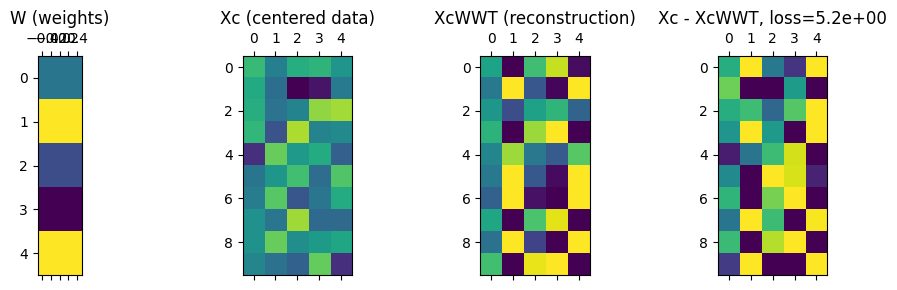

step    0  loss 5.1873998641967773
step  500  loss 0.5421682000160217
step 1000  loss 0.4423431158065796
step 1500  loss 0.4384756088256836
step 2000  loss 0.4384523034095764
step 2500  loss 0.4384522140026093
step 3000  loss 0.4384522140026093
step 3500  loss 0.4384522140026093
step 4000  loss 0.4384522140026093
step 4500  loss 0.4384522140026093
step 4999  loss 0.4384522140026093


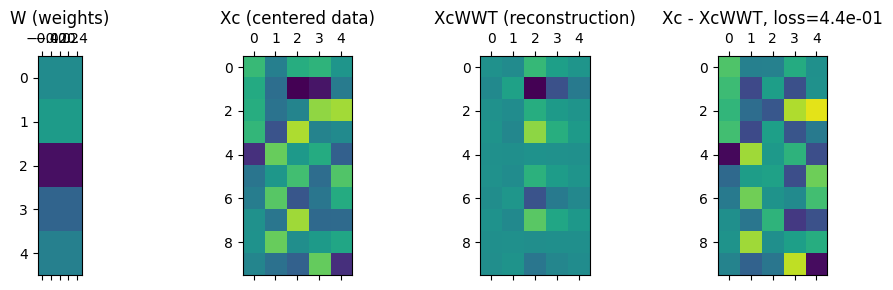

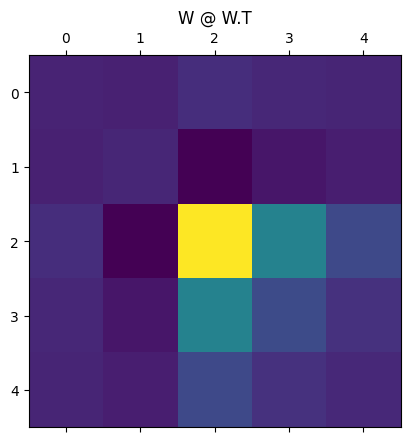



=========== k = 2 =============



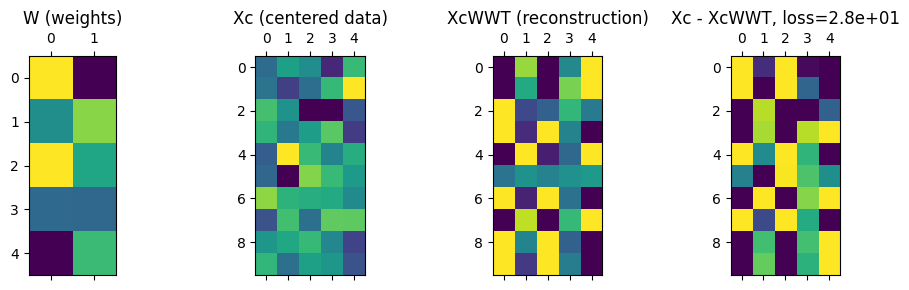

step    0  loss 27.5099487304687500
step  500  loss 0.6525291204452515
step 1000  loss 0.4531717300415039
step 1500  loss 0.3705327510833740
step 2000  loss 0.3564550876617432
step 2500  loss 0.3544033765792847
step 3000  loss 0.3541099429130554
step 3500  loss 0.3540643453598022
step 4000  loss 0.3540557920932770
step 4500  loss 0.3540539443492889
step 4999  loss 0.3540536761283875


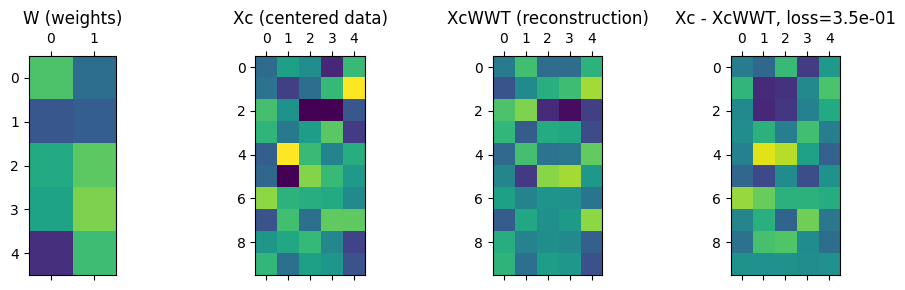

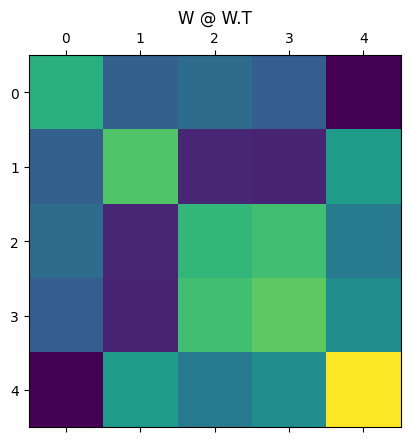



=========== k = 3 =============



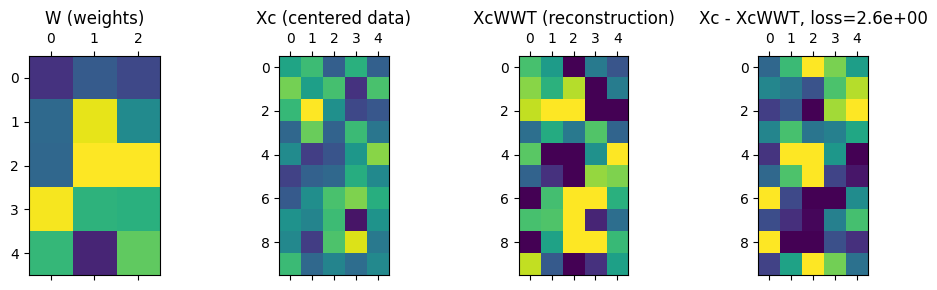

step    0  loss 2.6059236526489258
step  500  loss 0.0907448828220367
step 1000  loss 0.0907306671142578
step 1500  loss 0.0907306671142578
step 2000  loss 0.0907306671142578
step 2500  loss 0.0907306671142578
step 3000  loss 0.0907306745648384
step 3500  loss 0.0907306745648384
step 4000  loss 0.0907306745648384
step 4500  loss 0.0907306745648384
step 4999  loss 0.0907306745648384


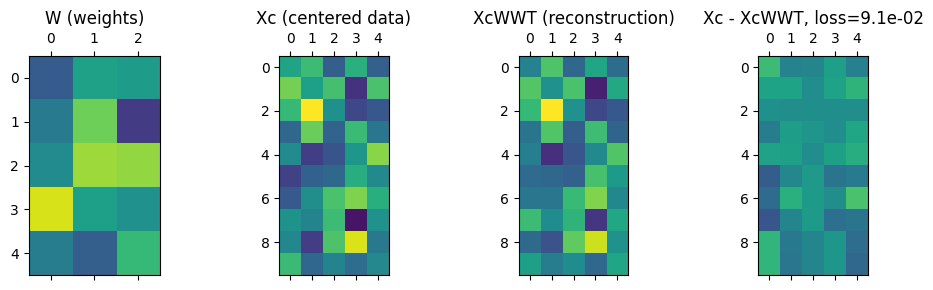

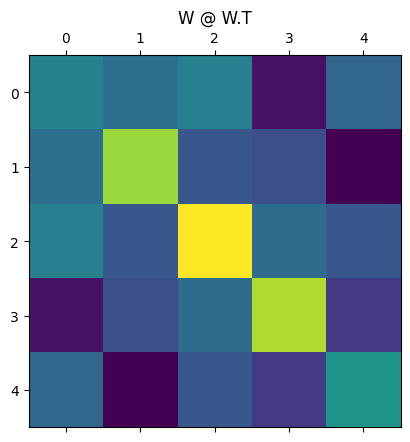



=========== k = 4 =============



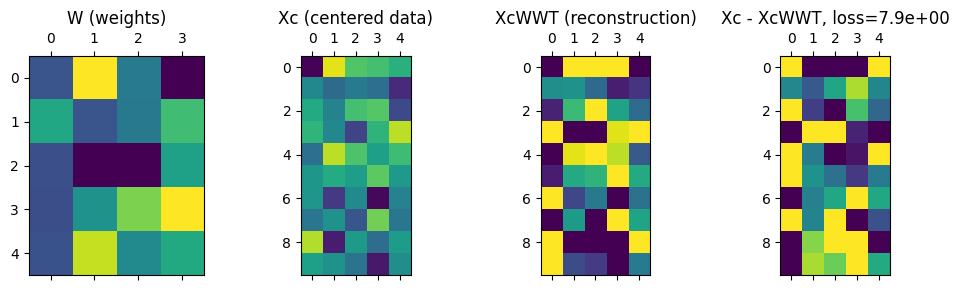

step    0  loss 7.9136781692504883
step  500  loss 0.0309507995843887
step 1000  loss 0.0188148003071547
step 1500  loss 0.0187288336455822
step 2000  loss 0.0187285561114550
step 2500  loss 0.0187285598367453
step 3000  loss 0.0187285598367453
step 3500  loss 0.0187285598367453
step 4000  loss 0.0187285598367453
step 4500  loss 0.0187285598367453
step 4999  loss 0.0187285598367453


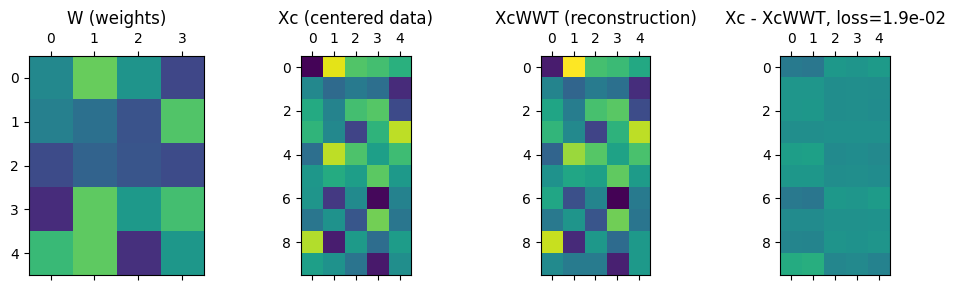

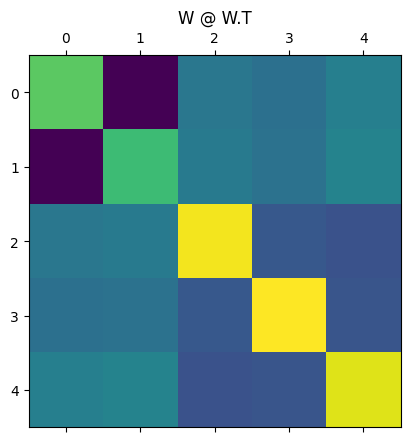



=========== k = 5 =============



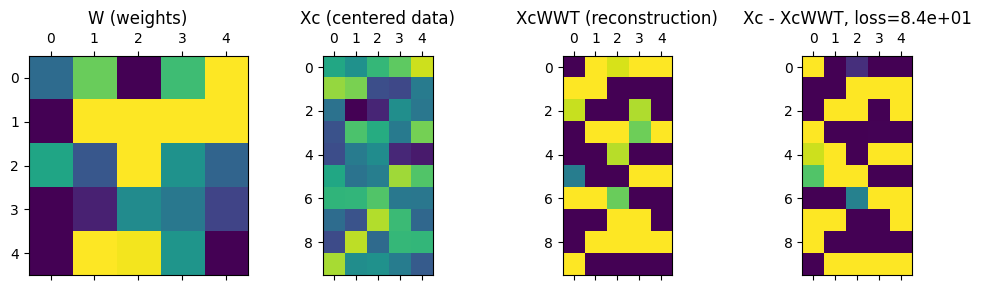

step    0  loss 83.6481628417968750
step  500  loss 0.0450418703258038
step 1000  loss 0.0008147276821546
step 1500  loss 0.0000202847368200
step 2000  loss 0.0000003668542661
step 2500  loss 0.0000000053798477
step 3000  loss 0.0000000001439513
step 3500  loss 0.0000000000772704
step 4000  loss 0.0000000000707537
step 4500  loss 0.0000000000705604
step 4999  loss 0.0000000000705604


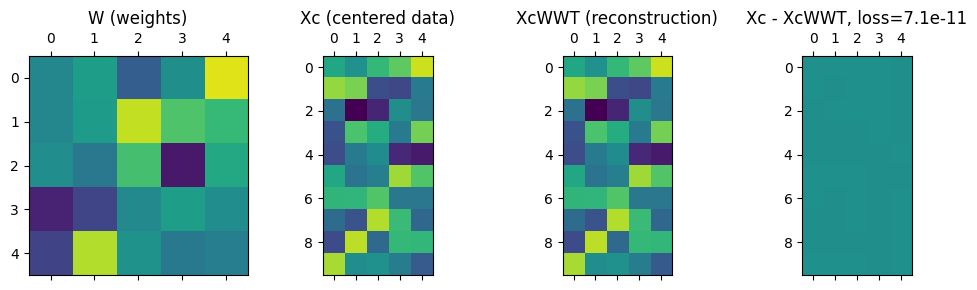

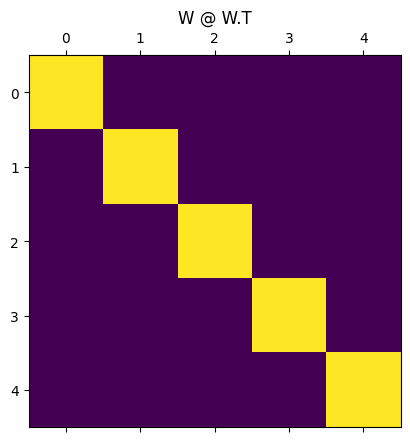

In [ ]:
N = 10
n = 5  
for k in range(1,6):
    print(f"\n\n=========== k = {k} =============\n")
    X = torch.randn(N, n)
    Xc = X - X.mean(0, keepdim=True)
    W = torch.randn(n, k, requires_grad=True)

    show_sgm(Xc, W)

    steps = 5000
    opt = torch.optim.Adam([W], lr=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=steps)  

    for step in range(steps):
        XcW   = Xc @ W          # (N, k)
        XcWWT = XcW @ W.T       # (N, n)
        loss  = F.mse_loss(XcWWT, Xc)
        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step()
        if step % (steps // 10) == 0 or step == steps-1: print(f"step {step:4d}  loss {loss.item():.16f}")

    show_sgm(Xc, W)
    plt.matshow((W @ W.T).detach())
    plt.title('W @ W.T')
    plt.show()

   #  eigenvalue is the way 

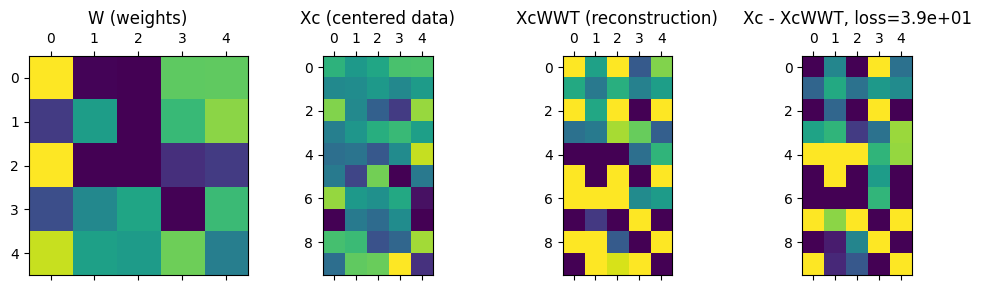

step    0  loss 38.5440635681152344
step  500  loss 0.0364351868629456
step 1000  loss 0.0005867668078281
step 1500  loss 0.0000052424707064
step 2000  loss 0.0000000222870025
step 2500  loss 0.0000000000736261
step 3000  loss 0.0000000000200661
step 3500  loss 0.0000000000201067
step 4000  loss 0.0000000000201067
step 4500  loss 0.0000000000201067
step 4999  loss 0.0000000000201067


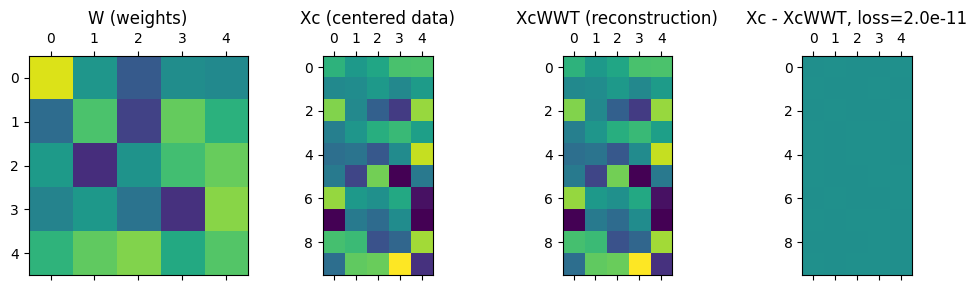

In [2]:
N = 10 
n = 5  
k = 5

X = torch.randn(N, n)
Xc = X - X.mean(0, keepdim=True)
W = torch.randn(n, k, requires_grad=True)

show_sgm(Xc, W)

steps = 5000
opt = torch.optim.Adam([W], lr=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=steps)  

for step in range(steps):
    XcW   = Xc @ W          # (N, k)
    XcWWT = XcW @ W.T       # (N, n)
    loss  = F.mse_loss(XcWWT, Xc)
    opt.zero_grad()
    loss.backward()
    opt.step()
    scheduler.step()
    if step % (steps // 10) == 0 or step == steps-1: print(f"step {step:4d}  loss {loss.item():.16f}")

show_sgm(Xc, W)

In [ ]:
# Ek wil weet hoe hierdie orthogonol vector in W vergelyk met wat produced sou wees as ek n SVD gedoen het.